## Importing Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Loading Data

- User_ID : 사용자 아이디
- Product_ID : 상품 아이디
- Gender : 성별
- Age : 나이 (범주화된 상태 '0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25')
- Occupation : 고객의 직업군 (?) (1 ~16)
- City_Category : 도시 (ABC)
- Stay_In_Current_City_Years : 지역 거주 기간 (0,1,2,3,4+)
- Marital_Status: 혼인 여부 (0,1)
- Product_Category: 상품 카테고리 (1~20)
- Purchase: 상품가

In [39]:
df = pd.read_csv('./data/walmart.csv')

## EDA

In [40]:
df.shape

(550068, 10)

In [41]:
# 중복된 User_ID가 있다. 
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [42]:
df.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [43]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [44]:
# 총 이용고객의 수 5891
df['User_ID'].nunique()

5891

## Visualization

VIP 고객 도출 및 지역별 구매 고객 특징을 파악하여 마케팅 전략을 도출


- 남성이 여성보다 43.4% 더 월마트를 이용한다.
- 총 구매 횟수가 가장 많은, 총 구매 금액이 가장 높은 구매자를 각각 5명씩 추출했을 때 성별이 남자였다. 

- 윌마트를 이용하는 가장 많은 고객은 B지역이나 상위 10%의 고객은 A 지역 출신이 많았다. 



In [188]:
# 남성 고객이 여성 고객보다 43.4 % 더 많다. 
df_gender = df.groupby('User_ID').Gender.unique().reset_index()
df_gender = df_gender.Gender.value_counts()
df_gender

[M]    4225
[F]    1666
Name: Gender, dtype: int64

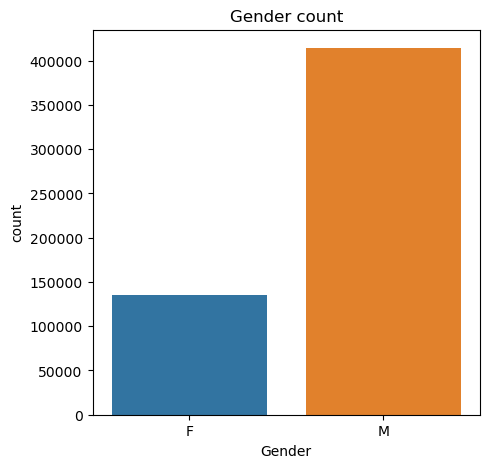

In [46]:
plt.figure(figsize=(5, 5))
sns.countplot(x='Gender',data=df)
plt.xlabel('Gender')
plt.ylabel('count')
plt.title('Gender count')
plt.show()

Text(0.5, 1.0, 'Age Distribution')

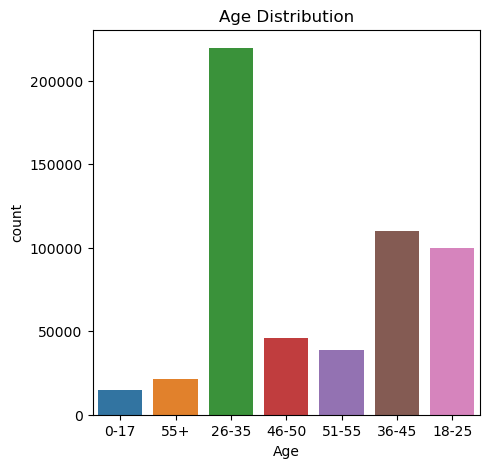

In [190]:
# 나이대별 구매 빈도수 
# 26-35세 나이대의 구매 빈도가 가장 높다. 
plt.figure(figsize=(5, 5))
sns.countplot(x='Age',data=df)
plt.xlabel('Age')
plt.ylabel('count')
plt.title('Age Distribution')

In [121]:
# B 지역이 구매 횟수가 가장 많다. 
df.City_Category.value_counts().sort_values(ascending=False)

B    231173
C    171175
A    147720
Name: City_Category, dtype: int64

Text(0.5, 1.0, 'City_Category')

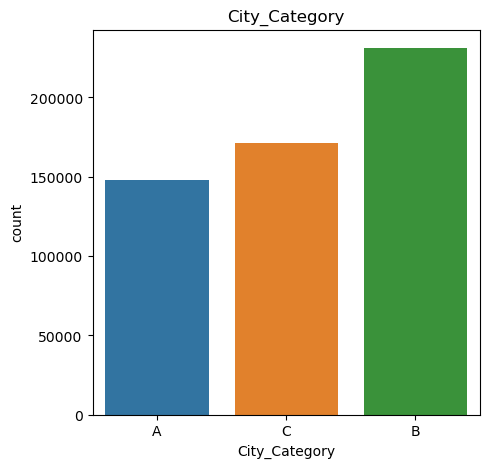

In [242]:
plt.figure(figsize=(5, 5))
sns.countplot(x='City_Category',data=df)
plt.xlabel('City_Category')
plt.ylabel('count')
plt.title('City_Category')

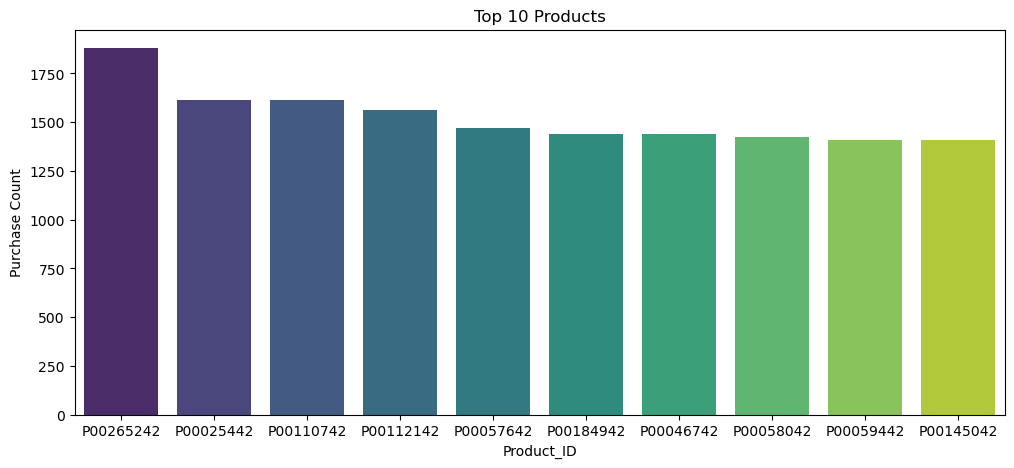

In [250]:
top10_products= df.Product_ID.value_counts().reset_index().head(10)
top10_products= top10_products.rename(columns={'index': 'Product_ID', 'Product_ID': 'Count'})

plt.figure(figsize=(12, 5))
sns.barplot(data=top10_products, x='Product_ID', y='Count', palette='viridis')
plt.title('Top 10 Products')
plt.xlabel('Product_ID')
plt.ylabel('Purchase Count')
plt.show()

In [248]:
# 1번 카테고리 항목이 가장 구매율이 많다. 
top10_products['Product_Category'] = df['Product_Category']
top10_products

,Product_ID,Count,Product_Category
0,P00265242,1880,3
1,P00025442,1615,1
2,P00110742,1612,12
3,P00112142,1562,12
4,P00057642,1470,8
5,P00184942,1440,1
6,P00046742,1438,1
7,P00058042,1422,1
8,P00059442,1406,1
9,P00145042,1406,8


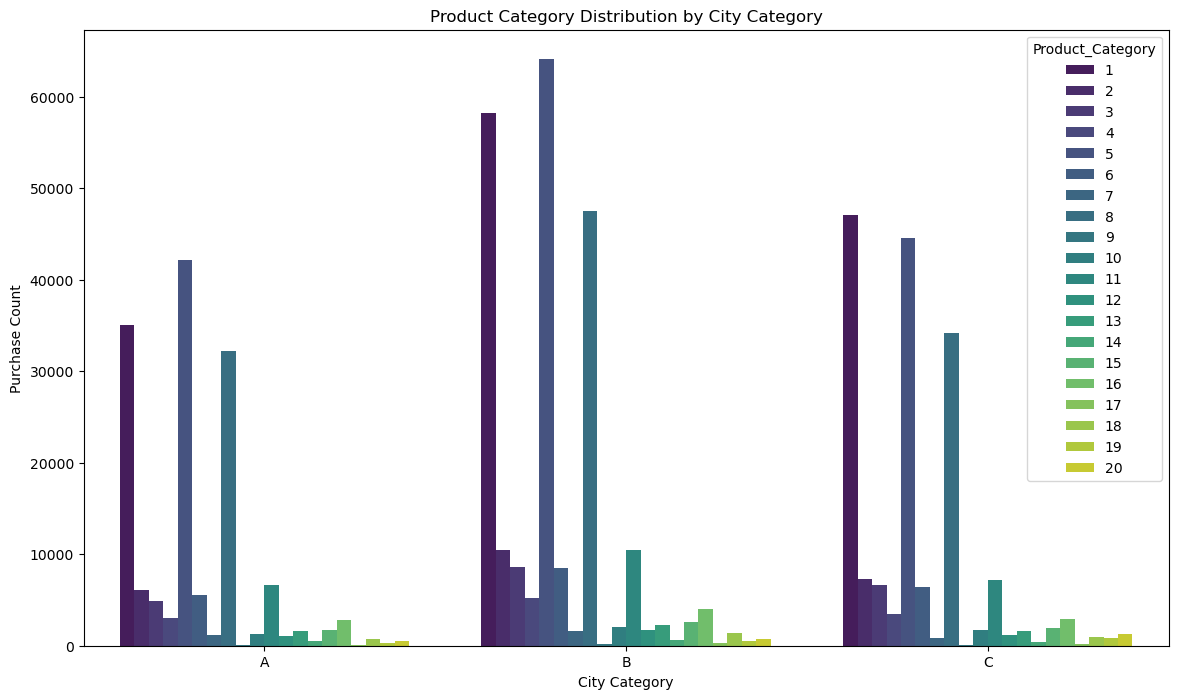

In [266]:
# 지역별 상품 카테고리 구매 분포 
category_counts_by_city = df.groupby(['City_Category', 'Product_Category']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=category_counts_by_city, x='City_Category', y='Count', hue='Product_Category', palette='viridis')
plt.title('Product Category Distribution by City Category')
plt.xlabel('City Category')
plt.ylabel('Purchase Count')
plt.show()


Text(0.5, 1.0, 'Stay_In_Current_City_Years')

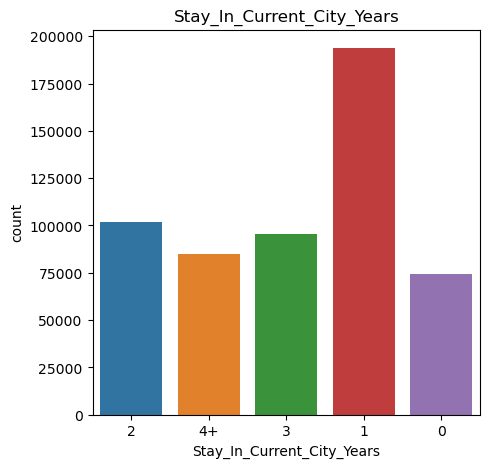

In [273]:
# 거주기간별 구매량
plt.figure(figsize=(5, 5))
sns.countplot(x='Stay_In_Current_City_Years',data=df)
plt.xlabel('Stay_In_Current_City_Years')
plt.ylabel('count')
plt.title('Stay_In_Current_City_Years')

###  VIP 고객은 누구인가?
- 윌마트를 이용하는 가장 많은 고객은 B지역이나 상위 10%의 고객은 A 지역 출신이 많았다.



In [176]:
#총 구매 횟수가 가장 높은 고객 10명 
customer_purchase_counts = df.groupby('User_ID').agg({'Purchase':'count' , 'Gender' :'first','Age':'first','City_Category':'first','Marital_Status':'first'}).reset_index()
customer_purchase_counts = customer_purchase_counts.sort_values(by='Purchase', ascending= False)
customer_purchase_counts.head(10)

,User_ID,Purchase,Gender,Age,City_Category,Marital_Status
1634,1001680,1026,M,26-35,A,1
4166,1004277,979,M,36-45,A,0
1885,1001941,898,M,36-45,A,0
1142,1001181,862,M,36-45,A,1
863,1000889,823,M,46-50,A,0
3520,1003618,767,M,55+,A,1
1111,1001150,752,F,26-35,A,0
981,1001015,740,M,36-45,A,1
5647,1005795,729,M,26-35,A,1
5683,1005831,727,M,26-35,A,1


In [185]:
# 구매 횟수가 높은 상위 10% 고객 
top_20_percent_index = int(len(customer_purchase_counts) * 0.1)
top_20_percent_customers_pc = customer_purchase_counts.iloc[:top_20_percent_index]
top_20_percent_customers_pc

,User_ID,Purchase,Gender,Age,City_Category,Marital_Status
1634,1001680,1026,M,26-35,A,1
4166,1004277,979,M,36-45,A,0
1885,1001941,898,M,36-45,A,0
1142,1001181,862,M,36-45,A,1
863,1000889,823,M,46-50,A,0
...,...,...,...,...,...,...
1727,1001776,227,M,26-35,B,1
1085,1001124,227,M,26-35,B,1
25,1000026,226,M,26-35,B,1
4775,1004897,225,M,36-45,B,0


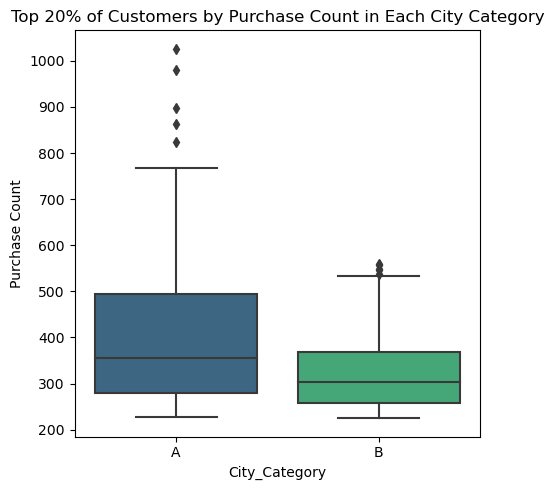

In [186]:
# 구매 횟수가 높은 상위 10% 고객 시각화 
plt.figure(figsize=(5, 5))
sns.boxplot(data=top_20_percent_customers_pc, x='City_Category', y='Purchase', palette='viridis')
plt.title('Top 20% of Customers by Purchase Count in Each City Category')
plt.ylabel('Purchase Count')
plt.xlabel('City_Category')

plt.tight_layout()
plt.show()

In [181]:
#총 구매 금액이 가장 높은 고객 
customer_purchase_buys = df.groupby('User_ID').agg({'Purchase':'sum' , 'Gender' :'first','Age':'first','City_Category':'first','Marital_Status':'first'}).reset_index()
customer_purchase_buys= customer_purchase_buys.sort_values(by='Purchase', ascending=False)


In [183]:
# 구매 금액이 높은 상위 10% 고객 
top_20_percent_index = int(len(customer_purchase_buys) * 0.1)
top_20_percent_customers_pb = customer_purchase_buys.iloc[:top_20_percent_index]
top_20_percent_customers_pb

,User_ID,Purchase,Gender,Age,City_Category,Marital_Status
4166,1004277,10536909,M,36-45,A,0
1634,1001680,8699596,M,26-35,A,1
2831,1002909,7577756,M,26-35,A,0
1885,1001941,6817493,M,36-45,A,0
416,1000424,6573609,M,26-35,A,0
...,...,...,...,...,...,...
3615,1003715,2075961,M,18-25,B,0
5384,1005523,2075512,M,36-45,B,1
2177,1002237,2075333,F,36-45,B,0
3526,1003624,2073593,M,26-35,B,1


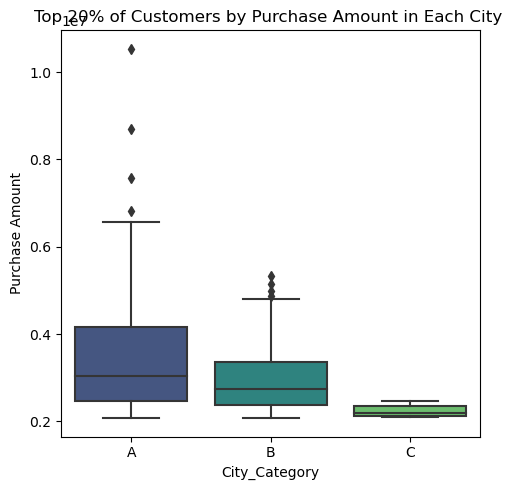

In [274]:
# 상위 10% 고객의 총 구매 금액 시각화 

plt.figure(figsize=(5, 5))
sns.boxplot(data=top_20_percent_customers_pb, x='City_Category', y='Purchase', palette='viridis')
plt.title('Top 20% of Customers by Purchase Amount in Each City ')
plt.ylabel('Purchase Amount')
plt.xlabel('City_Category')

plt.tight_layout()
plt.show()

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [261]:
cor_matrix = df.corr()
cor_matrix

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
User_ID,1.000000,-0.023971,0.020443,0.003825,0.004716
Occupation,-0.023971,1.000000,0.024280,-0.007618,0.020833
Marital_Status,0.020443,0.024280,1.000000,0.019888,-0.000463
Product_Category,0.003825,-0.007618,0.019888,1.000000,-0.343703
Purchase,0.004716,0.020833,-0.000463,-0.343703,1.000000


- 데이터 전처리, 탐색적 데이터 분석(EDA)을 통한 데이터의 분포 확인
- VIP 고객 도출 및 지역별 구매 고객 특징을 파악하여 마케팅 전략을 도출
- 데이터 상세: 약 55만개의 사용자 거래 내역과 10개의 특징(550068, 10)

In [ ]:
성별과 연령대, 직업군과 도시별, 결혼여부별, 거주기간별로 구매량을 확인하고 선호하는 품목 카테고리를 파악하여 어떤 그룹이 어떠한 제품군을 선호하며 가장 소비량이 많은지 확인한다. 
이를 통해 적은 비중의 고객 유형에 대해서는 신규 고객 유치를 위한 방향성에 대한 힌트를 얻고 기존의 고객중 가장 많은 매출이 발생했던 고객의 특징 역시 파악하고 강화하여 구매액수를 늘리기 위한 방법을 고안한다.

